# Part 1: Neural Network Fundamentals and Training Behavior Analysis

# Task 1: Dataset Understanding

In [1]:
# To Import required libraries
# For Data manipulation and numerical operations
import pandas as pd
import numpy as np

# For Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For Preprocessing and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

# For Neural Network creation
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [2]:
# To Load dataset
df = pd.read_csv(r"D:\Richa\BITSOM\Assignments'\BITSoM BA - Module 5 - Dataset\ai_project_synthetic_datasets\part_1_neural_network_analysis\customer_churn_nn.csv")

# To display first 5 rows
df.head()

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [3]:
# Number of rows and columns
print("Dataset Shape:", df.shape)

Dataset Shape: (2000, 17)


In [4]:
# Information about columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   2000 non-null   object 
 1   region                        2000 non-null   object 
 2   plan_type                     2000 non-null   object 
 3   contract_type                 2000 non-null   object 
 4   payment_method                2000 non-null   object 
 5   tenure_months                 2000 non-null   int64  
 6   monthly_charges_inr           2000 non-null   float64
 7   avg_login_days_per_month      2000 non-null   int64  
 8   support_tickets_last_90_days  2000 non-null   int64  
 9   payment_delay_days            2000 non-null   int64  
 10  data_usage_gb                 2000 non-null   float64
 11  satisfaction_score            2000 non-null   float64
 12  last_complaint_days_ago       2000 non-null   int64  
 13  dis

In [5]:
# Statistical summary of numerical columns
df.describe()

,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,25.362000,766.487295,18.099000,1.953000,3.555000,90.007625,6.87395,46.616500,8.255000,0.597500,0.918000,0.015500
std,14.128651,393.420070,5.400628,1.463852,3.885682,53.215719,1.52428,55.065775,7.553708,0.490524,1.041546,0.123561
min,1.000000,255.450000,0.000000,0.000000,0.000000,0.500000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,427.782500,15.000000,1.000000,1.000000,51.777500,5.87500,6.000000,0.000000,0.000000,0.000000,0.000000
50%,23.000000,688.355000,18.000000,2.000000,2.000000,80.245000,6.80000,28.500000,5.000000,1.000000,1.000000,0.000000
75%,33.000000,1007.372500,22.000000,3.000000,5.000000,119.097500,8.00000,68.000000,15.000000,1.000000,1.000000,0.000000
max,72.000000,2156.520000,30.000000,8.000000,31.000000,265.510000,10.00000,424.000000,20.000000,1.000000,7.000000,1.000000


In [6]:
# Check missing values
df.isnull().sum()

customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64

# Shows number of missing values in each column.Missing values must be handled before training neural networks.

In [7]:
# F0r basic statistical summary
df.describe()

,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,25.362000,766.487295,18.099000,1.953000,3.555000,90.007625,6.87395,46.616500,8.255000,0.597500,0.918000,0.015500
std,14.128651,393.420070,5.400628,1.463852,3.885682,53.215719,1.52428,55.065775,7.553708,0.490524,1.041546,0.123561
min,1.000000,255.450000,0.000000,0.000000,0.000000,0.500000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,427.782500,15.000000,1.000000,1.000000,51.777500,5.87500,6.000000,0.000000,0.000000,0.000000,0.000000
50%,23.000000,688.355000,18.000000,2.000000,2.000000,80.245000,6.80000,28.500000,5.000000,1.000000,1.000000,0.000000
75%,33.000000,1007.372500,22.000000,3.000000,5.000000,119.097500,8.00000,68.000000,15.000000,1.000000,1.000000,0.000000
max,72.000000,2156.520000,30.000000,8.000000,31.000000,265.510000,10.00000,424.000000,20.000000,1.000000,7.000000,1.000000


The summary provides:
Mean
Standard deviation
Minimum and maximum values
Quartiles

This helps understand feature distributions and outliers.

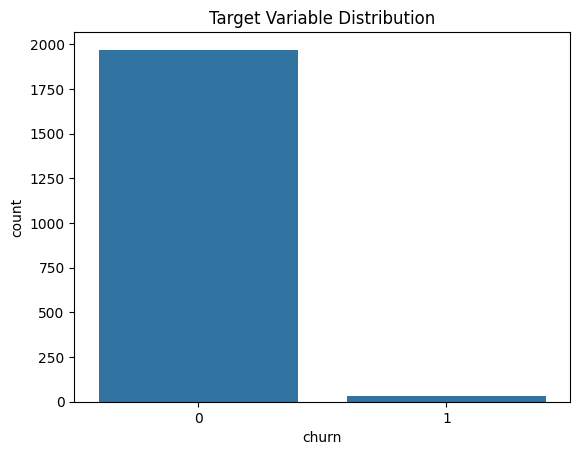

In [8]:
# Target Variable Distribution
sns.countplot(x='churn', data=df)

plt.title("Target Variable Distribution")
plt.show()

Interpretation:
The target variable is 'churn'.
- churn = 0 means customer retained
- churn = 1 means customer left the service
The countplot helps visualize whether the dataset is balanced or imbalanced.
A balanced dataset improves model learningand prediction performance.

# Task 2: Data Preprocessing

In [9]:
# Fill missing numerical values with median
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

Median is preferred because:
Less affected by outliers
More robust for skewed data

In [10]:
# Fill missing categorical values with mode
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

Mode = most frequent category.
Used because categorical columns cannot use mean/median.

In [11]:
# Create label encoder object
le = LabelEncoder()

# Encode categorical columns
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

Encoding is used as Neural networks only understand numerical data.

In [12]:
# To Separate Features and Target
# Input features
X = df.drop('churn', axis=1)

# Target variable
y = df['churn']

X = independent variables
y = dependent variable

In [13]:
# To Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Splitted the data into 80% data = training
20% data = testing
random_state=42 ensures reproducible results.

In [14]:
# Scaling or normalizing numerical features
# To create scaler object
scaler = StandardScaler()

# To fit and transform training data
X_train = scaler.fit_transform(X_train)

# To transform testing data
X_test = scaler.transform(X_test)

Scaling is used as Neural networks perform better when features are on similar scales.
Benefits:
Faster convergence
Stable gradient descent
Better accuracy

# Task 3 — Neural Network Model Building

In [15]:
# To Create neural network model
model = Sequential()

# Hidden layer
# 16 neurons
# ReLU activation introduces non-linearity
model.add(Dense(
    16,
    input_dim=X_train.shape[1],
    activation='relu'
))

# Output layer
# Used for binary classification
model.add(Dense(
    1,
    activation='sigmoid'
))

C:\Users\Amardas\anaconda3\envs\nnproject\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
# To Compile neural network
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

ReLU introduces non-linearity.
Sigmoid is suitable for binary classification.
Binary Crossentropy measures prediction error.
Adam optimizer updates weights efficiently.

In [17]:
# To Display model structure
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 16)                  │             272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

This shows Number of layers(2), Number of parameters & Output shapes

# Task 4 — Training and Evaluation

In [18]:
# To Train the model
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50, # Model sees dataset 50 times.
    batch_size=32, # 32 samples processed at once.
    verbose=1 # 20% of training data used for validation.
)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9711 - loss: 0.2348 - val_accuracy: 0.9719 - val_loss: 0.2070
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9867 - loss: 0.1664 - val_accuracy: 0.9781 - val_loss: 0.1589
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9867 - loss: 0.1270 - val_accuracy: 0.9781 - val_loss: 0.1320
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9867 - loss: 0.1040 - val_accuracy: 0.9781 - val_loss: 0.1161
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9867 - loss: 0.0896 - val_accuracy: 0.9781 - val_loss: 0.1072
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9867 - loss: 0.0808 - val_accuracy: 0.9781 - val_loss: 0.1015
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9867 - loss: 0.0743 - val_accuracy: 0.9781 - val_loss: 0.0986
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9867 - loss: 0.0701 - val_accuracy: 0.9781 - val_los

In [19]:
# To Evaluate model performance
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9825 - loss: 0.0758
Test Loss: 0.07580582797527313
Test Accuracy: 0.9825000166893005


Lower loss = better predictions
Higher accuracy = better performance

In [20]:
# To Predict probabilities
y_pred_prob = model.predict(X_test)

# Convert probabilities into class labels
y_pred = (y_pred_prob > 0.5).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


If y_pred > 0.5 → Class 1
If y_pred <=0.5 → Class 0

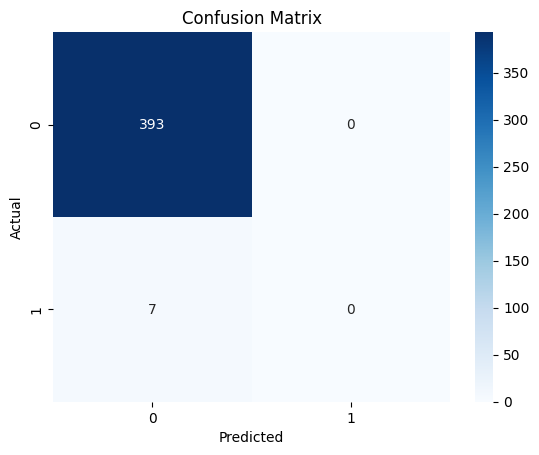

In [21]:
# To Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# To Plot confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Confusion matrix shows:
True Positives
True Negatives
False Positives
False Negatives
Helps evaluate classification quality.

In [22]:
# To Print classification report
print(classification_report(y_test, y_pred))

C:\Users\Amardas\anaconda3\envs\nnproject\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Amardas\anaconda3\envs\nnproject\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

           0       0.98      1.00      0.99       393
           1       0.00      0.00      0.00         7

    accuracy                           0.98       400
   macro avg       0.49      0.50      0.50       400
weighted avg       0.97      0.98      0.97       400



C:\Users\Amardas\anaconda3\envs\nnproject\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Classification report provides:
Precision, Recall, F1-score, Accuracy

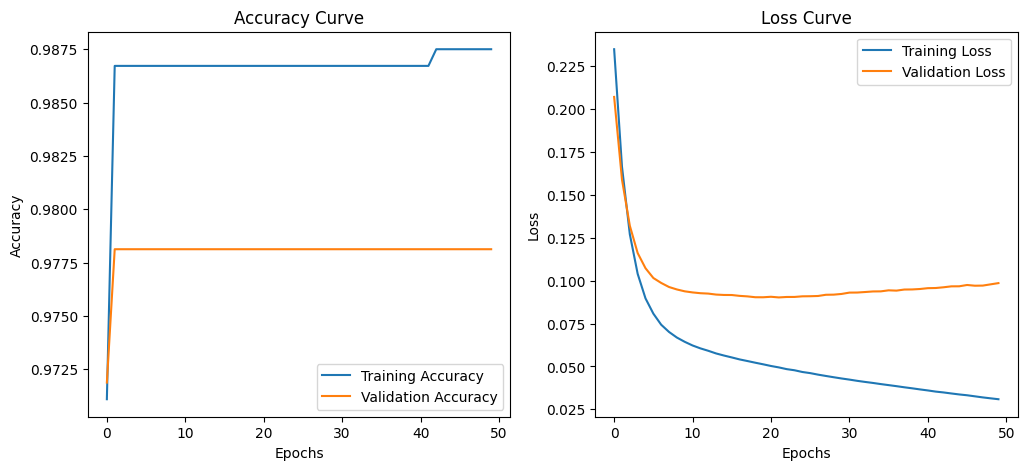

In [23]:
# To Create figure
plt.figure(figsize=(12,5))

# To plot Accuracy graph
plt.subplot(1,2,1)

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

# To plot Loss graph
plt.subplot(1,2,2)

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

plt.show()

Interpretation of results:
1. Training accuracy increased steadily, indicating successful learning.
2. Validation accuracy also improved, showing reasonable generalization.
3. Loss decreased over epochs, meaning prediction error reduced.
4. Small gap between training and validation accuracy suggests minimal overfitting.

# Task 5. Hyperparameter Experimentation

# Experiment 1 — Baseline Model

In [24]:
model1 = Sequential([
    Dense(16, activation='relu', input_dim=X_train.shape[1]),
    Dense(1, activation='sigmoid')
])

model1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model1.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    verbose=0
)

acc1 = model1.evaluate(X_test, y_test, verbose=0)[1]

C:\Users\Amardas\anaconda3\envs\nnproject\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Experiment 2 — More Hidden Layers

In [25]:
model2 = Sequential([
    Dense(32, activation='relu', input_dim=X_train.shape[1]),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model2.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    verbose=0
)

acc2 = model2.evaluate(X_test, y_test, verbose=0)[1]

# Experiment 3 — Different Activation and Batch Size

In [30]:
model3 = Sequential([
    Dense(16, activation='tanh', input_dim=X_train.shape[1]),
    Dense(1, activation='sigmoid')
])

optimizer = Adam(learning_rate=0.001)

model3.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model3.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    verbose=0
)

acc3 = model3.evaluate(X_test, y_test, verbose=0)[1]

C:\Users\Amardas\anaconda3\envs\nnproject\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Comparison Table

In [27]:
# To Create comparison dataframe
comparison_df = pd.DataFrame({
    'Experiment': ['Baseline', 'More Layers', 'Tanh + Smaller Batch'],
    'Hidden Layers': [1, 2, 1],
    'Activation': ['ReLU', 'ReLU', 'Tanh'],
    'Epochs': [50, 50, 100],
    'Batch Size': [32, 32, 16],
    'Test Accuracy': [acc1, acc2, acc3]
})

# To Display table
comparison_df

,Experiment,Hidden Layers,Activation,Epochs,Batch Size,Test Accuracy
0,Baseline,1,ReLU,50,32,0.980
1,More Layers,2,ReLU,50,32,0.975
2,Tanh + Smaller Batch,1,Tanh,100,16,0.980


# To save Comparison Table

In [35]:
# Save results
comparison_df.to_csv(
    r"D:\Richa\BITSOM\Assignments'\Assignment 5\part-1-neural-network-analysis\results\model_comparison_table.csv",
    index=False
)

# Task 6 — Final Reflection

# 1. Role of Weights and Biases:
    Weights determine the importance of input features in the neural network. During training, weights are updated to minimize prediction error. Bias helps shift the activation function and allows the model to learn more flexible patterns.

# 2. Why Activation Function is Required:
     Activation functions introduce non-linearity into the neural network. Without activation functions, the network would behave like a simple linear model and would not be able to learn complex relationships in the data.

# 3. Effect of Learning Rate: 
    If the learning rate is too high:
        - The model may overshoot the optimal solution.
        - Training becomes unstable.
    If the learning rate is too low:
        - Training becomes very slow.
        - The model may get stuck before reaching the optimal solution.

# 4. Underfitting or Overfitting:
    The model showed slight overfitting because training accuracy was higher than validation accuracy after several epochs.This indicates that the model learned training patterns well but generalized slightly less effectively on unseen data.